# 拡散モデル (Diffusion Model) with U-Net

## UNetを用いた拡散モデルの実装

### U-Net

In [2]:
import torch
from torch import nn

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )

    def forward(self, x):
        return self.convs(x)

In [4]:
class UNet(nn.Module):
    def __init__(self, in_ch=1):
        super().__init__()

        self.down1 = ConvBlock(in_ch=in_ch, out_ch=64)
        self.down2 = ConvBlock(in_ch=64, out_ch=128)
        self.bottom = ConvBlock(in_ch=128, out_ch=256)
        self.up2 = ConvBlock(in_ch=128 + 256, out_ch=128)
        self.up1 = ConvBlock(in_ch=128 + 64, out_ch=64)
        self.out = nn.Conv2d(in_channels=64, out_channels=in_ch, kernel_size=1)

        self.maxpool = nn.MaxPool2d(kernel_size=2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear')

    def forward(self, x):
        x1 = self.down1(x)
        x = self.maxpool(x1)
        x2 = self.down2(x)
        x = self.maxpool(x2)

        x = self.bottom(x)

        x = self.upsample(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x)
        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up1(x)
        x = self.out(x)

        return x

In [5]:
model = UNet()
x = torch.randn(10, 1, 28, 28) # dummy input
y = model(x)
print(y.shape)

torch.Size([10, 1, 28, 28])


### 正弦波位置エンコーディング

$$
\begin{equation}
v_{i} =
    \begin{cases}
        sin(\frac{t}{10000^{\frac{i}{D}}})   &   \text{(iが偶数の時)}  \\
        cos(\frac{t}{10000^{\frac{i}{D}}})   &   \text{(iが奇数の時)}
    \end{cases}
\end{equation}
$$

In [6]:
def _pos_encoding(t, output_dim, device='cpu'):
    D = output_dim
    v = torch.zeros(D, device=device)

    i = torch.arange(0, D, device=device)
    div_term = 10000**(i/D)

    v[0::2] = torch.sin(t / div_term[0::2])
    v[1::2] = torch.cos(t / div_term[1::2])

    return v

torch.Size([32])


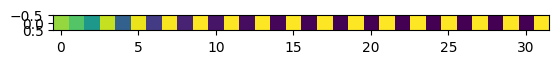

In [7]:
v = _pos_encoding(1, 32)
print(v.shape)
vp = v.numpy()

import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(vp.reshape(1, -1))


torch.Size([32])


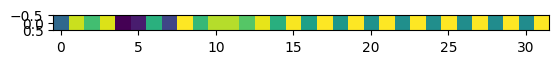

In [8]:
v = _pos_encoding(16, 32)
print(v.shape)
vp = v.numpy()

import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(vp.reshape(1, -1))


torch.Size([32])


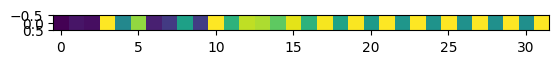

In [9]:
v = _pos_encoding(30, 32)
print(v.shape)
vp = v.numpy()

import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(vp.reshape(1, -1))

In [10]:
# バッチ型の正弦波位置エンコーディング
def pos_encoding(ts, output_dim, device='cpu'):
    batch_size = len(ts)
    v = torch.zeros(batch_size, output_dim, device=device)
    for i in range(batch_size):
        v[i] = _pos_encoding(ts[i], output_dim, device)
    return v

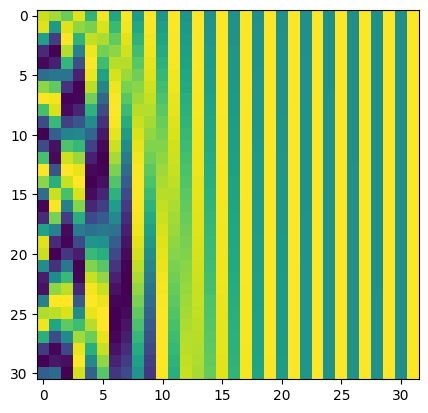

In [11]:
spe = pos_encoding(torch.arange(start=1, end=32, step=1), output_dim=32)
plt.imshow(spe.numpy())

torch.Size([3, 16])


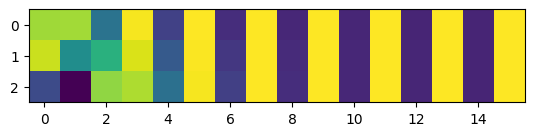

In [12]:
v = pos_encoding(torch.tensor([1,2,3]), 16)
print(v.shape)
plt.imshow(v.numpy())

### 正弦波位置エンコーディング組み込みConvBlock

In [13]:
class PosEncConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_embed_dim: int):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(in_channels=in_ch, out_channels=out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(num_features=out_ch),
            nn.ReLU(),
            nn.Conv2d(in_channels=out_ch, out_channels=out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(num_features=out_ch),
            nn.ReLU()
        )
        
        # 正弦波位置エンコーディングの非線形変換
        self.mlp = nn.Sequential(
            nn.Linear(in_features=time_embed_dim, out_features=in_ch),
            nn.ReLU(),
            nn.Linear(in_features=in_ch, out_features=in_ch)
        )

    def forward(self, x: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
        N, C, _, _ = x.shape
        v = self.mlp(v)
        v = v.view(N, C, 1, 1) # (N, C) -> (N, C, 1, 1)
        y = self.convs(x + v) # Input + Pos Enc
        return y


In [14]:
class TimeStepUNet(nn.Module):
    def __init__(self, in_ch: int = 1, time_embed_dim: int = 100):
        super().__init__()
        self.time_embed_dim = time_embed_dim

        self.down1 = PosEncConvBlock(in_ch, 64, time_embed_dim)
        self.down2 = PosEncConvBlock(64, 128, time_embed_dim)
        self.bottom = PosEncConvBlock(128, 256, time_embed_dim)
        self.up2 = PosEncConvBlock(128 + 256, 128, time_embed_dim)
        self.up1 = PosEncConvBlock(128 + 64, 64, time_embed_dim)
        self.out = nn.Conv2d(64, in_ch, kernel_size=1)

        self.maxpool = nn.MaxPool2d(kernel_size=2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear')

    def forward(self, x: torch.Tensor, timesteps: torch.Tensor):
        # 正弦波位置エンコーディング
        v = pos_encoding(ts=timesteps, output_dim=self.time_embed_dim, device=x.device)

        x1 = self.down1(x, v)
        x = self.maxpool(x1)
        x2 = self.down2(x, v)
        x = self.maxpool(x2)

        x = self.bottom(x, v)

        x = self.upsample(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x, v)
        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up1(x, v)
        x = self.out(x)
        return x



## 拡散過程

$$ q(x_{t} | x_{t-1}) = N(x_{t}; \sqrt{1-\beta_{t}}x_{t-1}, \beta_{t}I) $$
$$ \epsilon \sim N(0, I) $$
$$ x_{t} = \sqrt{1-\beta_{t}}x_{t-1} + \sqrt{\beta_{t}}\epsilon $$

ダミーデータによる実装と可視化

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.8021066..3.9511106].


Time steps: 0


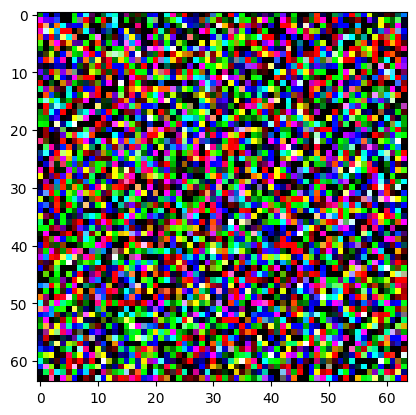

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.1122246..3.8600323].


Time steps: 200


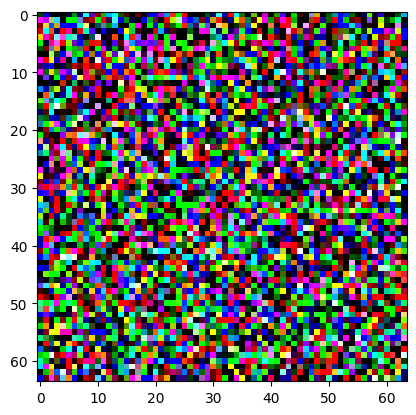

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.8684456..4.025147].


Time steps: 400


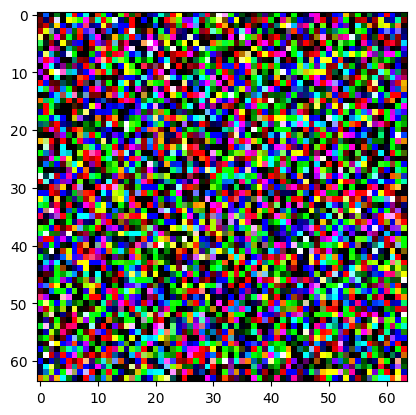

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.6627574..3.7390754].


Time steps: 600


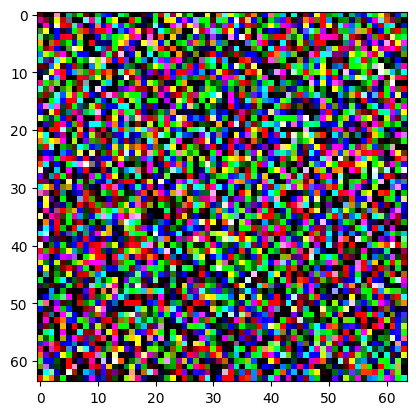

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.931367..4.1117597].


Time steps: 800


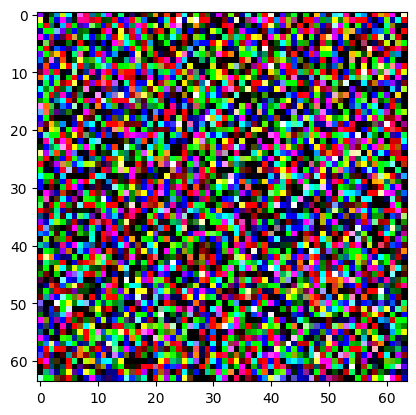

torch.Size([3, 64, 64])


In [15]:
x = torch.randn(3, 64, 64)
T = 1000
betas = torch.linspace(0.0001, 0.02, T) # ノイズスケジューリングは, 原論文に従って, 0.0001から0.02までに線形に変化する方法を採用
for t in range(T):
    beta = betas[t]
    eps = torch.randn_like(x) # xと同じ形状のガウスノイズを生成
    x = torch.sqrt(1 - beta) * x + torch.sqrt(beta) * eps

    if t % 200 == 0:
        print(f"Time steps: {t}")
        plt.imshow(x.clone().numpy().transpose(1,2,0))
        plt.show()

print(x.shape)

## 画像に対する拡散過程

c:\Users\inoue\Documents\MyGithub
c:\Users\inoue\Documents\MyGithub\Book_ZeroDeepLearning5
(124, 124, 3)


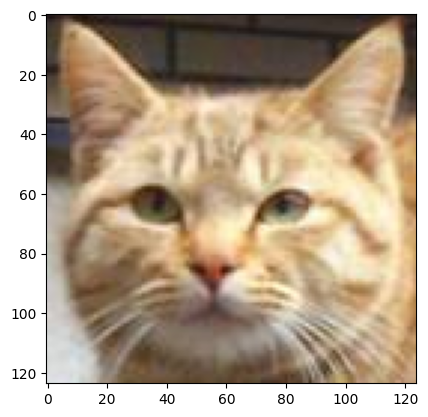

In [16]:
import os
import torchvision.transforms as TT
import numpy as np

# 画像の読み込み
# current_dir = os.path.dirname(os.path.abspath(__file__))
current_dir = os.path.dirname(os.getcwd())
print(current_dir)
current_dir = os.path.join(current_dir, 'Book_ZeroDeepLearning5')
print(current_dir)

file_path = os.sep.join([current_dir, 'Nekosan_Face.bmp'])
image = plt.imread(file_path)
print(image.shape)
plt.imshow(image)

In [17]:
# numpy -> tensor (0-1)
preprocess = TT.ToTensor()
x: torch.Tensor = preprocess(image)
print(x.size())
print(x.is_contiguous())
print(x.shape)

torch.Size([3, 124, 124])
True
torch.Size([3, 124, 124])


c:\Users\inoue\miniconda3_inoue_py311\envs\AIWorkPy311Env\Lib\site-packages\torchvision\transforms\functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


In [18]:
x_clone = x.clone()
print(x)


tensor([[[0.1412, 0.1451, 0.1569,  ..., 0.1569, 0.1529, 0.1412],
         [0.1373, 0.1059, 0.1294,  ..., 0.1961, 0.1765, 0.1882],
         [0.2078, 0.1804, 0.2078,  ..., 0.2314, 0.2039, 0.1961],
         ...,
         [0.8784, 0.8667, 0.8627,  ..., 0.7765, 0.8039, 0.8078],
         [0.8824, 0.8745, 0.8667,  ..., 0.7725, 0.7882, 0.7922],
         [0.8824, 0.8745, 0.8706,  ..., 0.7529, 0.7608, 0.7529]],

        [[0.0980, 0.1059, 0.1098,  ..., 0.1216, 0.1137, 0.1098],
         [0.1020, 0.0667, 0.0863,  ..., 0.1451, 0.1333, 0.1490],
         [0.1725, 0.1412, 0.1647,  ..., 0.1725, 0.1490, 0.1569],
         ...,
         [0.8824, 0.8706, 0.8588,  ..., 0.6392, 0.6627, 0.6745],
         [0.8863, 0.8784, 0.8706,  ..., 0.6353, 0.6510, 0.6588],
         [0.8980, 0.8902, 0.8863,  ..., 0.6196, 0.6275, 0.6196]],

        [[0.1137, 0.1098, 0.1098,  ..., 0.1020, 0.1059, 0.0980],
         [0.1059, 0.0706, 0.0784,  ..., 0.1216, 0.1176, 0.1412],
         [0.1765, 0.1373, 0.1490,  ..., 0.1529, 0.1373, 0.

In [19]:
# tensor -> numpy(image)
def reverse_to_img(x: torch.Tensor):
    x = x * 255
    x = x.clamp(0, 255)
    x = x.to(torch.uint8)
    to_pil = TT.ToPILImage()
    return to_pil(x)

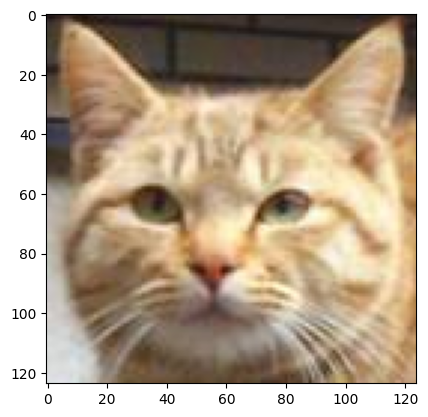

In [20]:
pil_img = reverse_to_img(x_clone)
plt.imshow(pil_img)

拡散過程を表示
+ 下記はループ処理による拡散過程

x.shape: torch.Size([3, 124, 124])


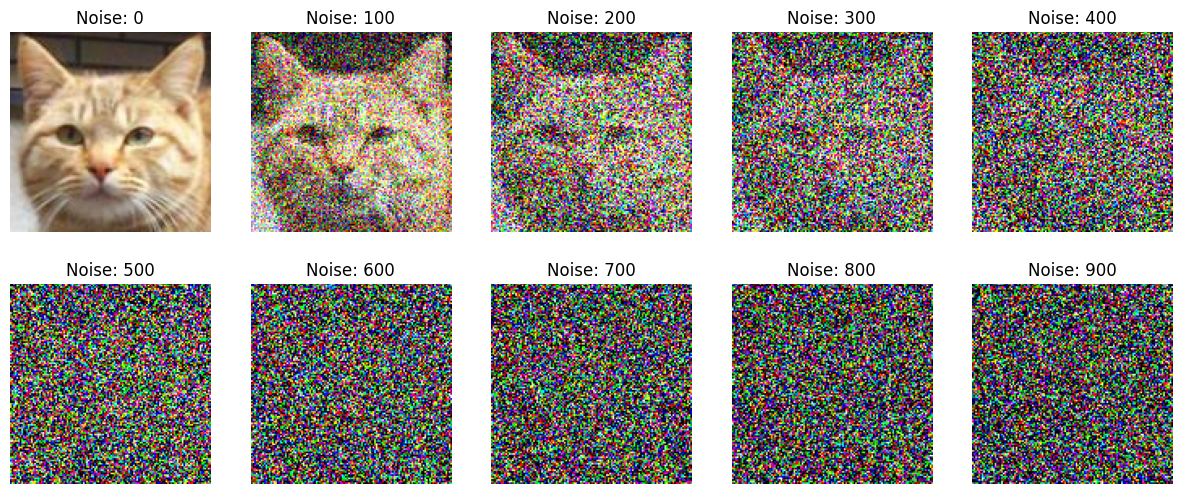

In [21]:
T = 1000
beta_start = 0.0001
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, T)
imgs = []

print(f"x.shape: {x.shape}")

for t in range(T):
    if t % 100 == 0:
        img = reverse_to_img(x)
        imgs.append(img)
    
    beta = betas[t]
    eps = torch.randn_like(x)
    x = torch.sqrt(1 - beta) * x + torch.sqrt(beta) * eps

# 10個の画像を2行5列で表示する
plt.figure(figsize=(15, 6))
for i, img in enumerate(imgs[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(f"Noise: {i * 100}")
    plt.axis('off')

plt.show()

### $ q(x_{t} | x_{0}) $ からのサンプリング

$$ \alpha_{t} = 1 - \beta_{t} $$
$$ \bar{\alpha_{t}} = \alpha_{t}\alpha{t-1}\cdots\alpha{1} $$
$$ q(x_{t} | x_{0}) = N(x_{t}; \sqrt{\bar{\alpha_{t}}}x_{0}, (1 - \bar{\alpha_{t}}I) $$
$$ \epsilon \sim N(0, I) $$
$$ x_{t} = \sqrt{\bar{\alpha_{t}}}x_{0} + \sqrt{1 - \bar{\alpha_{t}}}\epsilon $$

累積積(Cumulative Product)

In [22]:
input = torch.tensor([1,2,3,4])
output = torch.cumprod(input, dim=0)
print(output)

tensor([ 1,  2,  6, 24])


$ q(x_{t} | x_{0}) $ の実装

In [23]:
def add_noise(x_0, t, betas):
    T = len(betas)
    assert t >= 1 and t <= T

    alphas = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0) # 累積積
    t_idx = t - 1
    alpha_bar = alpha_bars[t_idx]

    eps = torch.randn_like(x_0)
    x_t = torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1 - alpha_bar) * eps

    return x_t

100回のループ処理による拡散過程ではなく, 1回の処理による拡散過程を実装

(124, 124, 3)
torch.Size([3, 124, 124])
True
torch.Size([3, 124, 124])


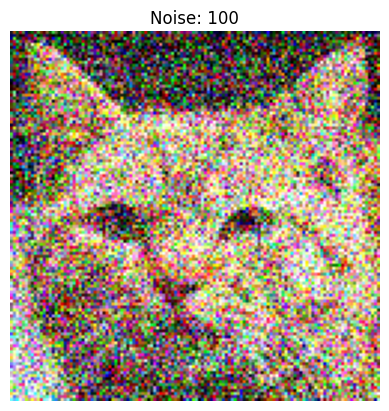

In [24]:
# 時刻100のノイズ画像を生成
file_path = os.sep.join([current_dir, 'Nekosan_Face.bmp'])
image = plt.imread(file_path)
print(image.shape)
plt.imshow(image)

# numpy -> tensor (0-1)
preprocess = TT.ToTensor()
x: torch.Tensor = preprocess(image)
print(x.size())
print(x.is_contiguous())
print(x.shape)

t = 100
x_t = add_noise(x, t, betas)

img = reverse_to_img(x_t)
plt.imshow(img)
plt.title(f"Noise: {t}")
plt.axis('off')
plt.show()

(124, 124, 3)
torch.Size([3, 124, 124])
True
torch.Size([3, 124, 124])


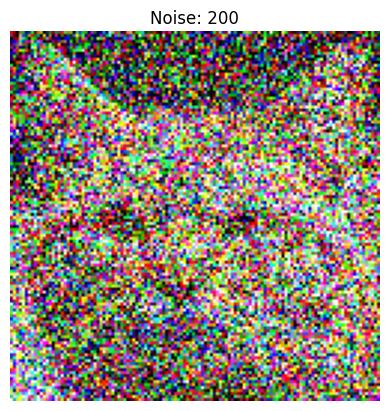

In [25]:
# 時刻200のノイズ画像を生成
file_path = os.sep.join([current_dir, 'Nekosan_Face.bmp'])
image = plt.imread(file_path)
print(image.shape)
plt.imshow(image)

# numpy -> tensor (0-1)
preprocess = TT.ToTensor()
x: torch.Tensor = preprocess(image)
print(x.size())
print(x.is_contiguous())
print(x.shape)

t = 200
x_t = add_noise(x, t, betas)

img = reverse_to_img(x_t)
plt.imshow(img)
plt.title(f"Noise: {t}")
plt.axis('off')
plt.show()

## Diffuserクラスの実装

In [26]:
class Diffuser:
    def __init__(self,
                 num_timesteps: int = 1000,
                 beta_start: float = 0.0001,
                 beta_end: float = 0.02,
                 device = 'cpu'):
        self.num_timesteps = num_timesteps
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0) # 累積積

    def add_noise(self, x_0: torch.Tensor, t: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        T = self.num_timesteps
        assert (t >= 1).all() and (t <= self.num_timesteps).all()
        t_idx = t - 1

        alpha_bar = self.alpha_bars[t_idx]
        N = alpha_bar.size(0)
        alpha_bar = alpha_bar.view(N, 1, 1, 1)

        noise = torch.randn_like(x_0, device=self.device)
        x_t: torch.Tensor = torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1 - alpha_bar) * noise

        return x_t, noise

## データ生成
+ $x_{t}$ から $ x_{0} $ を求める
```
x_t ~ N(0,I)
for i in [T...,1]:
  eps ~ N(0,I)
  if t == 1 then eps == 0:
  sigma_q_t = sqrt((1-a_t)(1-a_bar_t-1)/(1-a_bar_t))
  x_t-1 = (x_t - (1-a_t)/sqrt(1-a_bar_t)eps_teta(x_t,t))/sqrt(a_t) + sigma_q_t * eps
return x_0
```

In [31]:
from tqdm import tqdm

class Diffuser:
    def __init__(self,
                 num_timesteps: int = 1000,
                 beta_start: float = 0.0001,
                 beta_end: float = 0.02,
                 device = 'cpu'):
        self.num_timesteps = num_timesteps
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0) # 累積積

    def add_noise(self, x_0: torch.Tensor, t: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        T = self.num_timesteps
        assert (t >= 1).all() and (t <= self.num_timesteps).all()
        t_idx = t - 1

        alpha_bar = self.alpha_bars[t_idx]
        N = alpha_bar.size(0)
        alpha_bar = alpha_bar.view(N, 1, 1, 1)

        noise = torch.randn_like(x_0, device=self.device)
        x_t: torch.Tensor = torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1 - alpha_bar) * noise

        return x_t, noise
    
    def denoise(self, model, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        # tの各要素が1以上かつT以下であることを確認
        T = self.num_timesteps
        assert (t >= 1).all() and (t <= T).all()

        t_idx = t - 1
        alpha = self.alphas[t_idx]
        alpha_bar = self.alpha_bars[t_idx]
        alpha_bar_prev = self.alpha_bars[t_idx - 1]

        # ブロードキャストが正しく行われるための設定
        N = alpha.size(0)
        alpha = alpha.view(N, 1, 1, 1)
        alpha_bar = alpha_bar.view(N, 1, 1, 1)
        alpha_bar_prev = alpha_bar_prev.view(N, 1, 1, 1)

        model.eval() # BatchNormやDropoutなどtrainとevalで挙動が異なる演算を考慮
        with torch.no_grad():
            output_eps_of_model = model(x, t) # TimeStepUNet

        model.train()

        noise = torch.randn_like(x, device=self.device)
        noise[t == 1] = 0 # T=1のとき, epsを0にする

        mu = (x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * output_eps_of_model) / torch.sqrt(alpha)
        std = torch.sqrt((1 - alpha) * (1 - alpha_bar_prev) / (1 - alpha_bar))
        return mu + std * noise
    
    def reverse_to_img(self, x: torch.Tensor):
        x = x * 255
        x = x.clamp(0, 255)
        x = x.to(torch.uint8)
        x = x.cpu()
        to_pil = TT.ToPILImage()
        return to_pil(x)
    
    def sample(self, model, x_shape=(20, 1, 28, 28)):
        batch_size = x_shape[0]
        x = torch.randn(x_shape, device=self.device)

        for i in tqdm(range(self.num_timesteps, 0, -1)):
            t = torch.tensor([i] * batch_size, device=self.device, dtype=torch.long) # バッチサイズ分のT
            x = self.denoise(model, x, t)

        images = [self.reverse_to_img(x[i]) for i in range(batch_size)]
        return images

### 拡散モデルの学習
+ Diffuserクラス
+ TimeStepUNetクラス
+ DiffuserクラスとTimeStepUNetクラスを用いて拡散モデルの学習を行う

### 拡散モデルの学習アルゴリズム
```
Repeat:
  x_0 ~ q(x) # 学習データよりx_0をランダムに取得
  t ~ U{1,T} # 一様分布より整数tを生成
  eps ~ N(0,I)
  x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps # ~ q(x_t | x_0)
  (d/dΘ) || output_eps_of_model(x_t, t) - eps || ** 2 # 損失関数
```

100%|██████████| 1000/1000 [00:12<00:00, 78.99it/s]


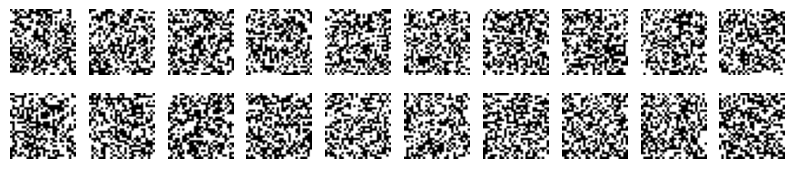

100%|██████████| 469/469 [01:01<00:00,  7.61it/s]


Epoch 0 | Loss: 0.048963072838813765


100%|██████████| 1000/1000 [00:12<00:00, 81.87it/s]


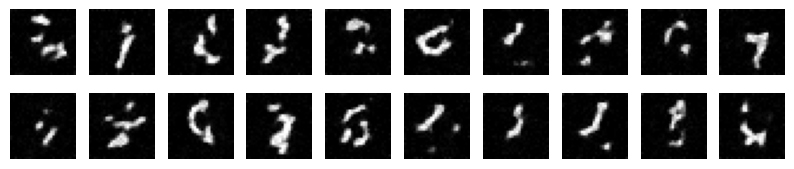

100%|██████████| 469/469 [01:01<00:00,  7.63it/s]


Epoch 1 | Loss: 0.027542668754167395


100%|██████████| 1000/1000 [00:12<00:00, 82.04it/s]


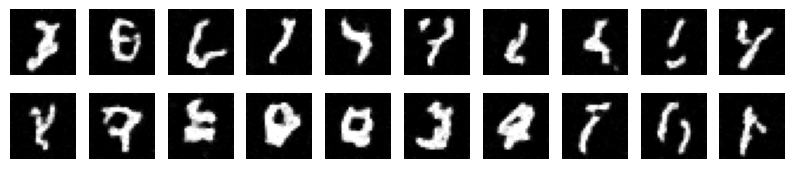

100%|██████████| 469/469 [01:01<00:00,  7.65it/s]


Epoch 2 | Loss: 0.024361017668472807


100%|██████████| 1000/1000 [00:12<00:00, 81.35it/s]


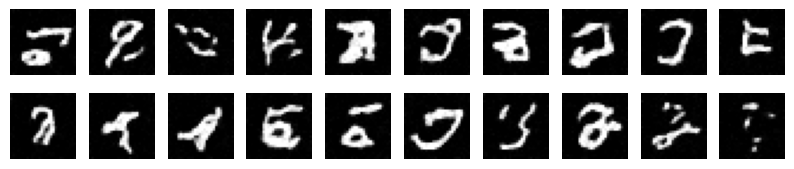

100%|██████████| 469/469 [01:02<00:00,  7.54it/s]


Epoch 3 | Loss: 0.02345368168406141


100%|██████████| 1000/1000 [00:13<00:00, 74.10it/s]


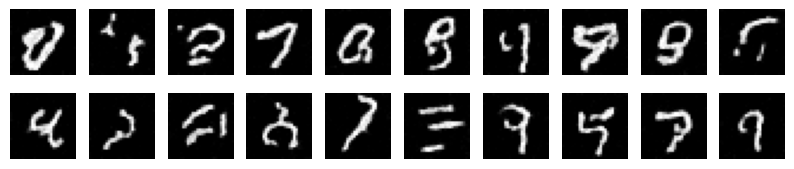

100%|██████████| 469/469 [01:04<00:00,  7.25it/s]


Epoch 4 | Loss: 0.021448858310657144


100%|██████████| 1000/1000 [00:13<00:00, 74.43it/s]


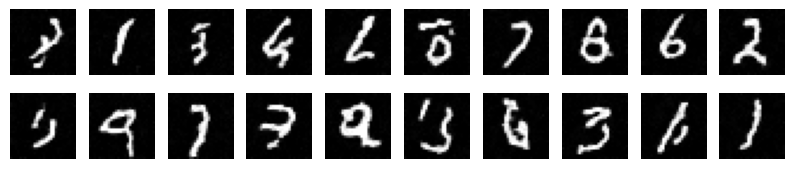

100%|██████████| 469/469 [01:06<00:00,  7.05it/s]


Epoch 5 | Loss: 0.02033205711439665


100%|██████████| 1000/1000 [00:14<00:00, 70.28it/s]


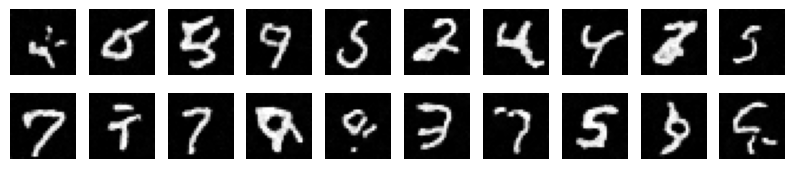

100%|██████████| 469/469 [01:06<00:00,  7.00it/s]


Epoch 6 | Loss: 0.0196955275120162


100%|██████████| 1000/1000 [00:13<00:00, 72.22it/s]


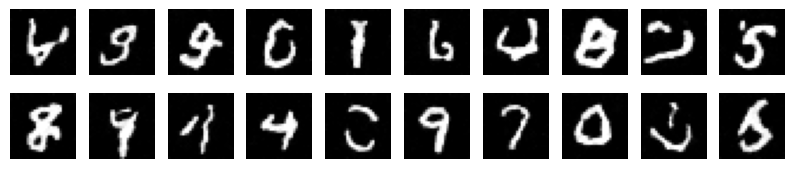

100%|██████████| 469/469 [01:06<00:00,  7.01it/s]


Epoch 7 | Loss: 0.019149388702931817


100%|██████████| 1000/1000 [00:14<00:00, 71.31it/s]


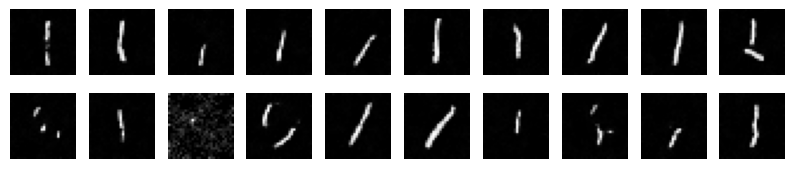

100%|██████████| 469/469 [01:07<00:00,  6.93it/s]


Epoch 8 | Loss: 0.018823132971361248


100%|██████████| 1000/1000 [00:14<00:00, 69.32it/s]


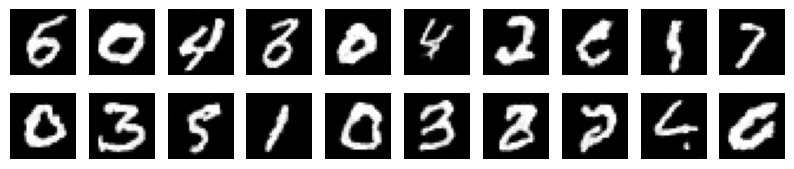

100%|██████████| 469/469 [01:14<00:00,  6.31it/s]

Epoch 9 | Loss: 0.01828523279666138


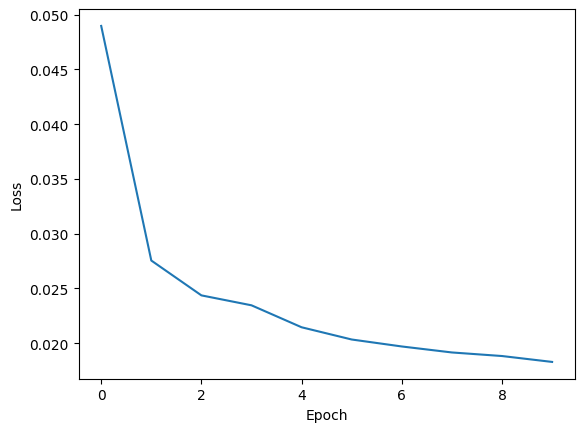

100%|██████████| 1000/1000 [00:15<00:00, 66.16it/s]


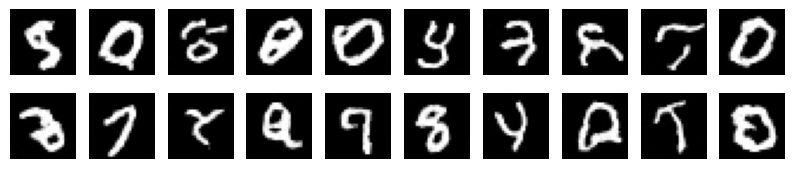

In [33]:
import math
import torch
import torchvision
import matplotlib.pyplot as plt
%matplotlib inline
from torchvision import transforms as TT
from torch.utils.data import DataLoader
from torch.optim import Adam
import torch.nn.functional as F
from torch import nn
from tqdm import tqdm

# MNIST
img_size = 28
batch_size = 128
num_timesteps = 1000
epochs = 10
lr = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def show_images(images, rows=2, cols=10):
    fig = plt.figure(figsize=(cols, rows))
    i = 0
    for r in range(rows):
        for c in range(cols):
            fig.add_subplot(rows, cols, i + 1)
            plt.imshow(images[i], cmap='gray')
            plt.axis('off') # 縦軸/横軸を非表示にする
            i += 1
    plt.show()

preprocess = TT.ToTensor()
ds = torchvision.datasets.MNIST(root='./data', download=True, transform=preprocess)
dl = DataLoader(ds, batch_size=batch_size, shuffle=True)
diffuser = Diffuser(num_timesteps=num_timesteps, device=device)
model = TimeStepUNet(in_ch=1)
model.to(device)
optimizer = Adam(model.parameters(), lr=lr)

# 学習
losses = []
for epoch in range(epochs):
    loss_sum = 0.0
    cnt = 0

    # エポック毎にデータ生成をして結果を確認したい場合コメントアウトを外す
    images = diffuser.sample(model)
    show_images(images)

    for images, labels in tqdm(dl):
        optimizer.zero_grad()
        x = images.to(device)
        t = torch.randint(1, num_timesteps + 1, (len(x),), device=device)

        # 時刻tのノイズ画像: x_noisy
        x_noisy, noise = diffuser.add_noise(x, t)
        # モデルにx_noisyとtを与えて, ノイズを予測させる
        noise_pred = model(x_noisy, t)
        # 損失関数
        loss = F.mse_loss(noise, noise_pred)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        cnt += 1

    loss_avg = loss_sum / cnt
    losses.append(loss_avg)
    print(f"Epoch {epoch} | Loss: {loss_avg}")

# 損失値のグラフ
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# 画像を生成
images = diffuser.sample(model)
show_images(images)
